In [16]:
import numpy as np
import pandas as pd

from pathlib import Path

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [17]:
ROOT = Path.cwd().parent

ruta_dataset = ROOT / "data" / "interim" / "dataset_eda.csv"

df = pd.read_csv(ruta_dataset)

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Dataset cargado correctamente.
Filas: 1914
Columnas: 106


In [18]:
if "IMC" not in df.columns:
    df["IMC"] = df["Q5"] / (df["Q4"] ** 2)

print("Variable IMC verificada correctamente.")

Variable IMC verificada correctamente.


In [19]:
df_regresion = df.dropna(subset=["IMC"]).copy()

print(f"Filas originales: {df.shape[0]}")
print(f"Filas con IMC válido: {df_regresion.shape[0]}")

Filas originales: 1914
Filas con IMC válido: 1737


In [20]:
# ======================================================
# Dataset de Regresión - Baseline
# ======================================================

features_baseline = [
    # Demografía
    "Q1", "Q2", "Q3",

    # Alimentación recodificada
    "QN6", "QN7", "QN8", "QN9", "QN10",

    # Actividad física / sedentarismo recodificado
    "QN49", "QN50", "QN51", "QN52"
]

target = "IMC"

dataset_regresion_baseline = df_regresion[
    features_baseline + [target]
].copy()

print("Dataset baseline creado.")
print(f"Variables predictoras baseline: {len(features_baseline)}")
print(dataset_regresion_baseline.shape)

# ======================================================
# Dataset de Regresión - Dirigido por el Dominio
# ======================================================

features_dominio = [
    # Demografía
    "Q1", "Q2", "Q3",

    # Alimentación e higiene alimentaria
    "Q6", "Q7", "Q8", "Q9", "Q10",
    "Q11", "Q12", "Q13", "Q14",

    # Actividad física / sedentarismo
    "Q49", "Q50", "Q51", "Q52"
]

dataset_regresion_dominio = df_regresion[
    features_dominio + [target]
].copy()

print("\nDataset de dominio creado.")
print(f"Variables predictoras dominio: {len(features_dominio)}")
print(dataset_regresion_dominio.shape)

dataset_regresion_dominio.head()


Dataset baseline creado.
Variables predictoras baseline: 12
(1737, 13)

Dataset de dominio creado.
Variables predictoras dominio: 16
(1737, 17)


,Q1,Q2,Q3,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q49,Q50,Q51,Q52,IMC
0,4.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,4.0,4.0,5.0,5.0,3.0,1.0,2.0,1.0,19.067711
1,3.0,1.0,1.0,3.0,2.0,2.0,4.0,2.0,2.0,5.0,5.0,3.0,4.0,1.0,2.0,4.0,20.690495
2,4.0,1.0,1.0,2.0,3.0,1.0,2.0,1.0,3.0,2.0,2.0,3.0,3.0,1.0,2.0,3.0,18.442546
3,5.0,2.0,1.0,1.0,3.0,3.0,4.0,7.0,5.0,5.0,5.0,5.0,1.0,2.0,6.0,1.0,31.501096
4,3.0,2.0,1.0,1.0,4.0,2.0,4.0,1.0,3.0,4.0,5.0,5.0,2.0,2.0,2.0,1.0,23.456558


In [21]:
columnas_excluir = [
    # Variables usadas para construir el IMC
    "Q4",
    "Q5",
    "Categoria_IMC",

    # Target
    "IMC",

    # Variables derivadas directamente del estado nutricional
    "qnowtg",
    "qnobeseg",
    "qnunwtg",

    # Variables de diseño muestral, no características del estudiante
    "weight",
    "stratum",
    "psu"
]

features_ampliado = [
    columna for columna in df_regresion.columns
    if columna not in columnas_excluir
]

dataset_regresion_ampliado = df_regresion[features_ampliado + [target]].copy()

print("Dataset ampliado creado.")
print(f"Variables predictoras ampliadas: {len(features_ampliado)}")
print(dataset_regresion_ampliado.shape)

Dataset ampliado creado.
Variables predictoras ampliadas: 96
(1737, 97)


In [22]:
dataset_regresion_dominio.isnull().sum().sort_values(ascending=False)

Q51    43
Q52    23
Q8     22
Q12    22
Q50    21
Q3     20
Q11    18
Q14    13
Q6     12
Q7     12
Q49    12
Q10    10
Q13     7
Q9      6
Q1      0
Q2      0
IMC     0
dtype: int64

In [23]:
print("Columnas excluidas:")
for columna in columnas_excluir:
    print("-", columna)

Columnas excluidas:
- Q4
- Q5
- Categoria_IMC
- IMC
- qnowtg
- qnobeseg
- qnunwtg
- weight
- stratum
- psu


In [24]:
print("Primeras 20 variables predictoras:")
print(features_ampliado[:20])

print("\nÚltimas 20 variables predictoras:")
print(features_ampliado[-20:])

Primeras 20 variables predictoras:
['Q1', 'Q2', 'Q3', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21', 'Q22']

Últimas 20 variables predictoras:
['QN44', 'QN45', 'QN46', 'QN47', 'QN48', 'QN49', 'QN50', 'QN51', 'QN52', 'QN53', 'QN54', 'QN55', 'QN56', 'QN57', 'QN58', 'qnfrvgg', 'qnpa7g', 'qnpe5g', 'qnc1g', 'qnc2g']


In [25]:
print("Nulos en baseline:")
display(dataset_regresion_baseline.isnull().sum().sort_values(ascending=False).head(20))

print("Nulos en dominio:")
display(dataset_regresion_dominio.isnull().sum().sort_values(ascending=False).head(20))

print("Nulos en ampliado:")
display(dataset_regresion_ampliado.isnull().sum().sort_values(ascending=False).head(20))


Nulos en baseline:


QN51    43
QN52    23
QN8     22
QN50    21
Q3      20
QN49    12
QN7     12
QN6     12
QN10    10
QN9      6
Q1       0
Q2       0
IMC      0
dtype: int64

Nulos en dominio:


Q51    43
Q52    23
Q8     22
Q12    22
Q50    21
Q3     20
Q11    18
Q14    13
Q6     12
Q7     12
Q49    12
Q10    10
Q13     7
Q9      6
Q1      0
Q2      0
IMC     0
dtype: int64

Nulos en ampliado:


qnc2g    1616
qnc1g    1572
QN40     1537
QN47     1432
QN48     1431
QN45     1418
QN37     1415
QN21     1407
QN36     1375
QN18     1327
QN19     1315
QN34     1133
QN17      177
Q17       177
Q19       152
Q34       135
Q18       102
QN44       84
Q44        84
Q20        74
dtype: int64

In [26]:
ruta_processed = ROOT / "data" / "processed"
ruta_processed.mkdir(parents=True, exist_ok=True)

dataset_regresion_baseline.to_csv(
    ruta_processed / "dataset_regresion_baseline.csv",
    index=False
)

dataset_regresion_dominio.to_csv(
    ruta_processed / "dataset_regresion_dominio.csv",
    index=False
)

dataset_regresion_ampliado.to_csv(
    ruta_processed / "dataset_regresion_ampliado.csv",
    index=False
)

print("Datasets de regresión guardados correctamente.")
print(ruta_processed / "dataset_regresion_baseline.csv")
print(ruta_processed / "dataset_regresion_dominio.csv")
print(ruta_processed / "dataset_regresion_ampliado.csv")


Datasets de regresión guardados correctamente.
/MachineLearning_GSHS/data/processed/dataset_regresion_baseline.csv
/MachineLearning_GSHS/data/processed/dataset_regresion_dominio.csv
/MachineLearning_GSHS/data/processed/dataset_regresion_ampliado.csv


In [27]:
print("Verificación de archivos de regresión generados:")
print((ROOT / "data" / "processed" / "dataset_regresion_baseline.csv").exists())
print((ROOT / "data" / "processed" / "dataset_regresion_dominio.csv").exists())
print((ROOT / "data" / "processed" / "dataset_regresion_ampliado.csv").exists())


Verificación de archivos de regresión generados:
True
True
True


In [28]:
# ==========================================================
# PREPROCESAMIENTO PARA CLASIFICACIÓN
# ==========================================================

In [37]:
# ==========================================================
# Crear variable objetivo (0 = No Riesgo, 1 = Riesgo)
# ==========================================================

df_clasificacion = df.copy()

df_clasificacion["Riesgo_Salud_Mental"] = (
    df_clasificacion["QN24"]
    .replace({
        1: 1,   # Sí hay riesgo
        2: 0    # No hay riesgo
    })
)

print(df_clasificacion["Riesgo_Salud_Mental"].value_counts())


Riesgo_Salud_Mental
0.0    1622
1.0     267
Name: count, dtype: int64


In [38]:
features_clasificacion = [

    # Demografía
    "Q1",
    "Q2",
    "Q3",

    # Bullying
    "Q20",
    "Q21",

    # Alcohol
    "Q34",
    "Q35",
    "Q36",
    "Q37",
    "Q38",
    "Q39",

    # Relación con los padres
    "Q55",
    "Q56",
    "Q57",
    "Q58"

]

target = "Riesgo_Salud_Mental"

In [39]:
dataset_clasificacion = df_clasificacion[
    features_clasificacion + [target]
].copy()

dataset_clasificacion.head()

,Q1,Q2,Q3,Q20,Q21,Q34,Q35,Q36,Q37,Q38,Q39,Q55,Q56,Q57,Q58,Riesgo_Salud_Mental
0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,5.0,1.0,1.0,0.0
1,3.0,1.0,1.0,2.0,5.0,3.0,1.0,1.0,1.0,1.0,1.0,2.0,5.0,5.0,1.0,0.0
2,4.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,5.0,2.0,3.0,0.0
3,5.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,5.0,1.0,1.0
4,3.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,4.0,5.0,1.0,0.0


In [40]:
dataset_clasificacion = dataset_clasificacion.dropna(
    subset=[target]
)

print(dataset_clasificacion.shape)

(1889, 16)


In [41]:
dataset_clasificacion["Riesgo_Salud_Mental"].value_counts()

Riesgo_Salud_Mental
0.0    1622
1.0     267
Name: count, dtype: int64

In [42]:
(
    dataset_clasificacion["Riesgo_Salud_Mental"]
    .value_counts(normalize=True)
    * 100
)

Riesgo_Salud_Mental
0.0    85.865537
1.0    14.134463
Name: proportion, dtype: float64

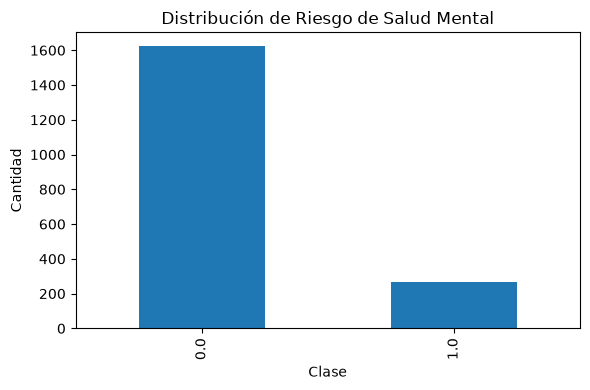

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

dataset_clasificacion["Riesgo_Salud_Mental"] \
    .value_counts() \
    .plot(kind="bar")

plt.title("Distribución de Riesgo de Salud Mental")

plt.xlabel("Clase")

plt.ylabel("Cantidad")

plt.tight_layout()

plt.show()

In [44]:
ruta_processed = ROOT / "data" / "processed"
ruta_processed.mkdir(parents=True, exist_ok=True)

dataset_clasificacion.to_csv(
    ruta_processed / "dataset_clasificacion.csv",
    index=False
)

print("Dataset de clasificación guardado correctamente.")
print(ruta_processed / "dataset_clasificacion.csv")


Dataset de clasificación guardado correctamente.
/MachineLearning_GSHS/data/processed/dataset_clasificacion.csv
